In [2]:
from src.phenotype import phenotype
from src.genotype import Genotype
from src.display import load_img, display_n_grid

import numpy as np

population = np.load('checkpoints/ch_7040.npy')
target = load_img(imgfile='data/among_us.png')

w,h = target.shape

phenotypes = [phenotype(p, image_data=(w,h)) for p in population]

display_n_grid(phenotypes, pad=10, max_h=800)

255

In [3]:
x = [1,2,3,4]

x[-3:]

[2, 3, 4]

In [4]:
import numpy as np

evaluations = [1, 2, 1.5, 3, 10, 0]    

order = np.argsort(evaluations)[::-1]
ranking = np.empty_like(order); ranking[order] = np.arange(len(order))

ranking

array([4, 2, 3, 1, 0, 5])

In [8]:
np.random.rand() < 0.5

True

Processing N=50
Processing N=100
Processing N=200
Processing N=500
Processing N=1000
Processing N=5000


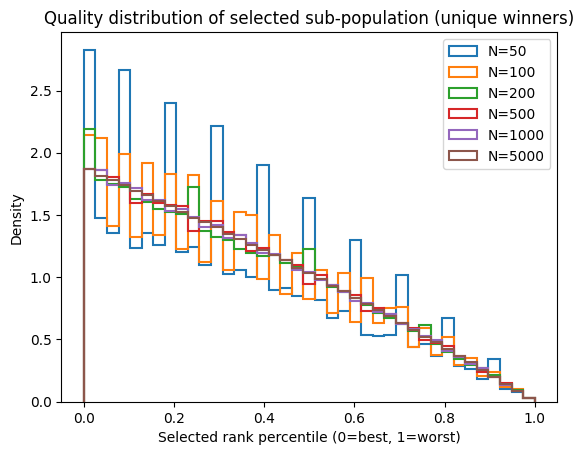

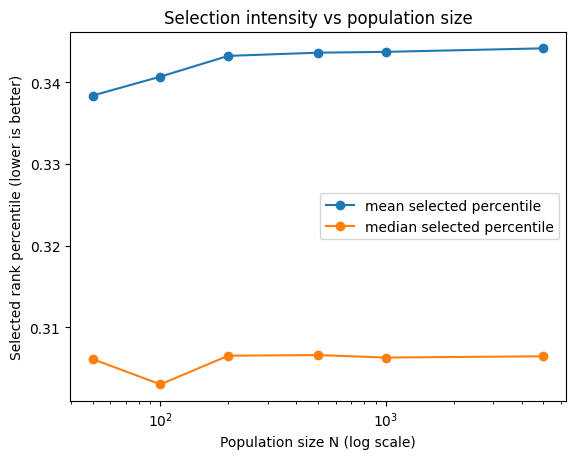

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def tournament_winners(rankings: np.ndarray, n_select: int, k: int = 2) -> np.ndarray:
    """Return winner indices for each tournament (allowing repeats)."""
    N = len(rankings)
    winners = np.empty(n_select, dtype=int)
    for t in range(n_select):
        idx = np.random.choice(N, size=k, replace=False)
        winners[t] = idx[np.argmin(rankings[idx])]  # lower rank = better
    return winners

def simulate_selection_quality(
    N_list=(50, 100, 200, 500, 1000),
    n_select_frac=1/3,
    k=2,
    trials=1000,
):
    """
    For each N:
      - create rankings = 0..N-1 (0 best)
      - run many trials of tournament selection
      - collect winner rank percentiles (0 best, 1 worst)
    """
    out = {}
    for N in N_list:
        print(f"Processing N={N}")
        rankings = np.arange(N)  # simplest: rank == index
        n_select = max(1, int(round(n_select_frac * N)))

        # collect all winners across trials
        all_pct = []
        unique_pct = []
        for _ in range(trials):
            w = tournament_winners(rankings, n_select=n_select, k=k)
            pct = rankings[w] / (N - 1)  # percentile-ish in [0,1]
            all_pct.append(pct)

            u = np.unique(w)
            unique_pct.append(rankings[u] / (N - 1))

        out[N] = {
            "all_pct": np.concatenate(all_pct),
            "unique_pct": np.concatenate(unique_pct),
        }
    return out

# ---- run ----
res = simulate_selection_quality(
    N_list=[50, 100, 200, 500, 1000, 5000],
    n_select_frac=0.2,
    k=2,
    trials=2000,
)

# ---- plot distributions (density hist) ----
plt.figure()
bins = np.linspace(0, 1, 40)

for N, d in res.items():
    plt.hist(d["unique_pct"], bins=bins, density=True, histtype="step", linewidth=1.5, label=f"N={N}")

plt.xlabel("Selected rank percentile (0=best, 1=worst)")
plt.ylabel("Density")
plt.title("Quality distribution of selected sub-population (unique winners)")
plt.legend()
plt.show()

# ---- plot summary: mean/median selected percentile vs N ----
Ns = np.array(sorted(res.keys()))
means = np.array([res[N]["unique_pct"].mean() for N in Ns])
meds  = np.array([np.median(res[N]["unique_pct"]) for N in Ns])

plt.figure()
plt.plot(Ns, means, marker="o", label="mean selected percentile")
plt.plot(Ns, meds,  marker="o", label="median selected percentile")
plt.xscale("log")
plt.xlabel("Population size N (log scale)")
plt.ylabel("Selected rank percentile (lower is better)")
plt.title("Selection intensity vs population size")
plt.legend()
plt.show()
